# Selecting the Number of Clusters with Silhouette Analysis

This notebook evaluates different numbers of clusters for K-Means using silhouette analysis.

The analysis tests the following candidate values:

- `k = 2`
- `k = 3`
- `k = 4`
- `k = 5`
- `k = 6`

For each candidate value of `k`, the notebook:

1. Fits a K-Means clustering model.
2. Calculates the average silhouette score.
3. Calculates the silhouette coefficient for every observation.
4. Creates a silhouette distribution plot.
5. Visualizes the predicted clusters and centroids.
6. Records inertia, cluster sizes, cluster centers, and silhouette statistics.
7. Saves the important plots and numerical results.

The silhouette coefficient ranges from `-1` to `1`.

- A value close to `1` indicates that an observation is well matched to its assigned cluster.
- A value close to `0` indicates that an observation is close to a cluster boundary.
- A negative value suggests that an observation may have been assigned to an unsuitable cluster.

The final number of clusters should not be selected using only one metric. Silhouette score, inertia, cluster-size balance, visual separation, and practical interpretation should be considered together.

## Import Libraries and Configure Project Folders

This section imports the Python libraries required for data handling, K-Means clustering, silhouette analysis, visualization, and result storage.

The notebook automatically detects whether it is running from the project root folder or from the `notebooks` folder. It then creates the required output folders:

- `plots/number_of_clusters`
- `results/number_of_clusters`

In [1]:
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score


def find_project_root(start_path):
    """
    Find the main project folder containing:
    data/, notebooks/, plots/, and results/.
    """
    current_path = Path(start_path).resolve()

    # Check the current folder and its parent folders
    for folder in [current_path, *current_path.parents]:

        required_folders = [
            folder / "data",
            folder / "notebooks",
            folder / "plots",
            folder / "results",
        ]

        if all(path.is_dir() for path in required_folders):
            return folder

    raise FileNotFoundError(
        "The project root could not be found. "
        "Make sure the project contains data, notebooks, plots, and results folders."
    )


# Current folder from which Jupyter is running
CURRENT_DIR = Path.cwd().resolve()

# Find the main project folder
ROOT_DIR = find_project_root(CURRENT_DIR)

# Correct notebook folder and notebook file
NOTEBOOK_DIR = ROOT_DIR / "notebooks" / "module_2"
NOTEBOOK_PATH = NOTEBOOK_DIR / "06_number_of_clusters.ipynb"

# Output folders for this notebook
PLOTS_DIR = ROOT_DIR / "plots" / "number_of_clusters"
RESULTS_DIR = ROOT_DIR / "results" / "number_of_clusters"

# Create output folders if they do not already exist
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Display the detected folder paths
print("=" * 100)
print("PROJECT FOLDER CONFIGURATION")
print("=" * 100)
print(f"Current folder  : {CURRENT_DIR}")
print(f"Project root    : {ROOT_DIR}")
print(f"Notebook folder : {NOTEBOOK_DIR}")
print(f"Notebook file   : {NOTEBOOK_PATH}")
print(f"Plots folder    : {PLOTS_DIR}")
print(f"Results folder  : {RESULTS_DIR}")
print("=" * 100)

# Check whether the folders and notebook exist
print("\nPATH CHECK")
print("-" * 100)
print(f"Project root exists    : {ROOT_DIR.exists()}")
print(f"Notebook folder exists : {NOTEBOOK_DIR.exists()}")
print(f"Notebook file exists   : {NOTEBOOK_PATH.exists()}")
print(f"Plots folder exists    : {PLOTS_DIR.exists()}")
print(f"Results folder exists  : {RESULTS_DIR.exists()}")

PROJECT FOLDER CONFIGURATION
Current folder  : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Project root    : C:\Users\samsa\Documents\Capstone Project\Project
Notebook folder : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Notebook file   : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\06_number_of_clusters.ipynb
Plots folder    : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters
Results folder  : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters

PATH CHECK
----------------------------------------------------------------------------------------------------
Project root exists    : True
Notebook folder exists : True
Notebook file exists   : True
Plots folder exists    : True
Results folder exists  : True


##### Explaination :
The project folders are now configured successfully.

All plots created in this notebook will be saved in:

`root_folder/plots/number_of_clusters`

All numerical results, cluster assignments, cluster centers, and text reports will be saved in:

`root_folder/results/number_of_clusters`

## Configure Display and Plot Settings

This section configures how tables and figures are displayed in the notebook.

The settings improve table readability, increase saved-figure quality, and apply consistent formatting to all plots.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (9, 7),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titleweight": "bold",
    }
)

print("Notebook display and plotting settings configured successfully.")

Notebook display and plotting settings configured successfully.


##### Explanation :
The notebook will now display all DataFrame columns, use four decimal places for numerical values, and save plots at 300 dots per inch.

The higher figure resolution makes the saved PNG files suitable for reports, presentations, and academic documentation.

## Generate the Synthetic Dataset

The official silhouette-analysis example uses `make_blobs()` to generate a two-dimensional synthetic dataset.

The dataset contains:

- 500 observations
- 2 numerical features
- 4 generating centers
- A cluster standard deviation of 1.0
- A fixed random state for reproducibility

The generating group labels are retained only for reference. They are not provided to K-Means and are not used when calculating silhouette scores.

In [3]:
N_SAMPLES = 500
N_FEATURES = 2
TRUE_CENTERS = 4
CLUSTER_STANDARD_DEVIATION = 1.0
DATA_RANDOM_STATE = 1


X, generated_group = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=TRUE_CENTERS,
    cluster_std=CLUSTER_STANDARD_DEVIATION,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=DATA_RANDOM_STATE,
)


print("=" * 70)
print("SYNTHETIC DATASET GENERATED")
print("=" * 70)
print(f"Number of observations : {X.shape[0]}")
print(f"Number of features     : {X.shape[1]}")
print(f"Generating centers     : {TRUE_CENTERS}")
print(f"Cluster standard dev.  : {CLUSTER_STANDARD_DEVIATION}")
print("=" * 70)

SYNTHETIC DATASET GENERATED
Number of observations : 500
Number of features     : 2
Generating centers     : 4
Cluster standard dev.  : 1.0


##### Observations :
The generated dataset contains $500$ observations and two numerical features.

Although the data were generated from four centers, the clustering models will not receive this information. Each model must identify the cluster structure using only the two numerical features.

## Create and Save the Dataset Table

This section converts the generated NumPy arrays into a structured pandas DataFrame.

The table contains:

- A unique sample identifier
- Feature 1
- Feature 2
- The original generating group

The dataset is saved as `sample_data.csv` for reproducibility and later inspection.

In [4]:
sample_data_df = pd.DataFrame(
    {
        "Sample_ID": np.arange(1, len(X) + 1),
        "Feature_1": X[:, 0],
        "Feature_2": X[:, 1],
        "Generated_Group": generated_group,
    }
)


sample_data_path = RESULTS_DIR / "sample_data.csv"

sample_data_df.to_csv(
    sample_data_path,
    index=False,
)


print(f"Dataset saved to: {sample_data_path}")

display(sample_data_df.head())

Dataset saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\sample_data.csv


,Sample_ID,Feature_1,Feature_2,Generated_Group
0,1,-6.9232,-10.6695,2
1,2,-8.6306,-7.1394,2
2,3,-9.6305,-2.7204,1
3,4,-2.3065,5.3080,0
4,5,-7.5701,-3.0145,3


##### Explanation :
The displayed table confirms that every observation has a unique sample identifier and two numerical feature values.

The `Generated_Group` column records the group used during data generation. It is stored only as a reference and is not used to train or evaluate the K-Means models.

## Visualize the Original Dataset

This plot displays the synthetic observations before applying K-Means.

No cluster labels are shown. This allows the visible structure of the dataset to be examined without using either the generating labels or the predicted K-Means labels.

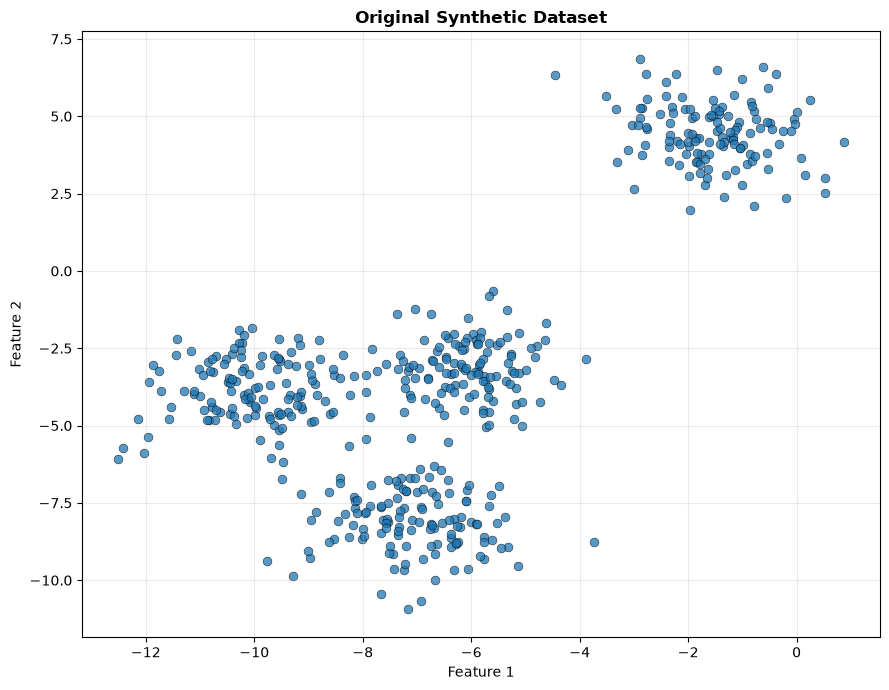

Sample data plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\sample_data.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    X[:, 0],
    X[:, 1],
    s=40,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
)

ax.set_title("Original Synthetic Dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

fig.tight_layout()

sample_plot_path = PLOTS_DIR / "sample_data.png"

fig.savefig(
    sample_plot_path,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Sample data plot saved to: {sample_plot_path}")

##### Explanation :

The plot shows one visually distinct group in the upper-right region and several groups that are closer together in the lower-left region.

This structure explains why different values of `k` may produce different conclusions. For example, a smaller value of `k` may combine several nearby groups, while a larger value may divide existing groups into unnecessary smaller clusters.

## Define Candidate Values of K

This section defines the candidate numbers of clusters that will be evaluated.

The analysis tests `k = 2, 3, 4, 5, and 6`.

Several containers are also created to store:

- Model-level performance metrics
- Cluster sizes
- Cluster centers
- Cluster assignments
- Fitted K-Means models

In [6]:
RANGE_N_CLUSTERS = [2, 3, 4, 5, 6]
KMEANS_RANDOM_STATE = 10


metrics_rows = []
cluster_size_rows = []
center_rows = []

assignment_df = sample_data_df[
    ["Sample_ID", "Feature_1", "Feature_2"]
].copy()

fitted_models = {}


print(f"Candidate values of k: {RANGE_N_CLUSTERS}")
print(f"K-Means random state  : {KMEANS_RANDOM_STATE}")

Candidate values of k: [2, 3, 4, 5, 6]
K-Means random state  : 10


##### Explanation :
The same random state will be used for every candidate model so that the comparison remains reproducible.

The result containers will be populated during the K-Means analysis and later converted into pandas DataFrames.

## Define the Silhouette Visualization Function

This function creates the main two-panel visualization for each candidate value of `k`.

The left panel shows the silhouette distribution of every cluster.

The right panel shows the observations colored by their predicted K-Means cluster, together with the cluster centroids.

In [7]:
def create_silhouette_figure(
    features,
    cluster_labels,
    silhouette_values,
    silhouette_average,
    model,
    n_clusters,
):
    """Create and save a silhouette-analysis figure."""

    fig, (ax1, ax2) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(18, 7),
    )

    # Left panel: silhouette distributions
    ax1.set_xlim([-0.2, 1.0])
    ax1.set_ylim(
        [0, len(features) + (n_clusters + 1) * 10]
    )

    y_lower = 10

    for cluster_number in range(n_clusters):

        current_values = silhouette_values[
            cluster_labels == cluster_number
        ]

        current_values.sort()

        cluster_size = len(current_values)
        y_upper = y_lower + cluster_size

        cluster_color = cm.nipy_spectral(
            float(cluster_number) / n_clusters
        )

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            current_values,
            facecolor=cluster_color,
            edgecolor=cluster_color,
            alpha=0.7,
        )

        ax1.text(
            -0.08,
            y_lower + (cluster_size / 2),
            str(cluster_number),
        )

        y_lower = y_upper + 10

    ax1.axvline(
        x=silhouette_average,
        linestyle="--",
        linewidth=2,
        label=f"Average = {silhouette_average:.4f}",
    )

    ax1.set_title("Silhouette Plot for Individual Clusters")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xticks(
        [-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    )
    ax1.legend(loc="lower right")

    # Right panel: cluster assignments
    point_colors = cm.nipy_spectral(
        cluster_labels.astype(float) / n_clusters
    )

    ax2.scatter(
        features[:, 0],
        features[:, 1],
        marker=".",
        s=50,
        linewidth=0,
        alpha=0.75,
        c=point_colors,
    )

    centers = model.cluster_centers_

    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        s=250,
        edgecolor="black",
        linewidth=1.5,
    )

    for cluster_number, center in enumerate(centers):

        ax2.scatter(
            center[0],
            center[1],
            marker=f"${cluster_number}$",
            s=70,
            edgecolor="black",
        )

    ax2.set_title("K-Means Cluster Assignments")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")

    fig.suptitle(
        f"Silhouette Analysis for K-Means with k = {n_clusters}",
        fontsize=16,
        fontweight="bold",
    )

    fig.tight_layout(rect=[0, 0, 1, 0.94])

    plot_path = PLOTS_DIR / f"silhouette_k{n_clusters}.png"

    fig.savefig(
        plot_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    return plot_path

##### Explanation :
The function does not fit a clustering model. It only receives the results of a fitted model and creates the corresponding visualization.

Separating the plotting logic into a function makes the main analysis easier to read and avoids repeating the same plotting code for every candidate value of `k`.

## Run K-Means and Silhouette Analysis

This is the main analysis step.

For every candidate value of `k`, the code:

1. Fits a K-Means model using K-Means++ initialization.
2. Predicts the cluster assignment of every observation.
3. Calculates the average silhouette score.
4. Calculates observation-level silhouette values.
5. Calculates inertia and cluster-size statistics.
6. Records the cluster centers.
7. Creates and saves the silhouette-analysis figure.

FITTING K-MEANS WITH k = 2


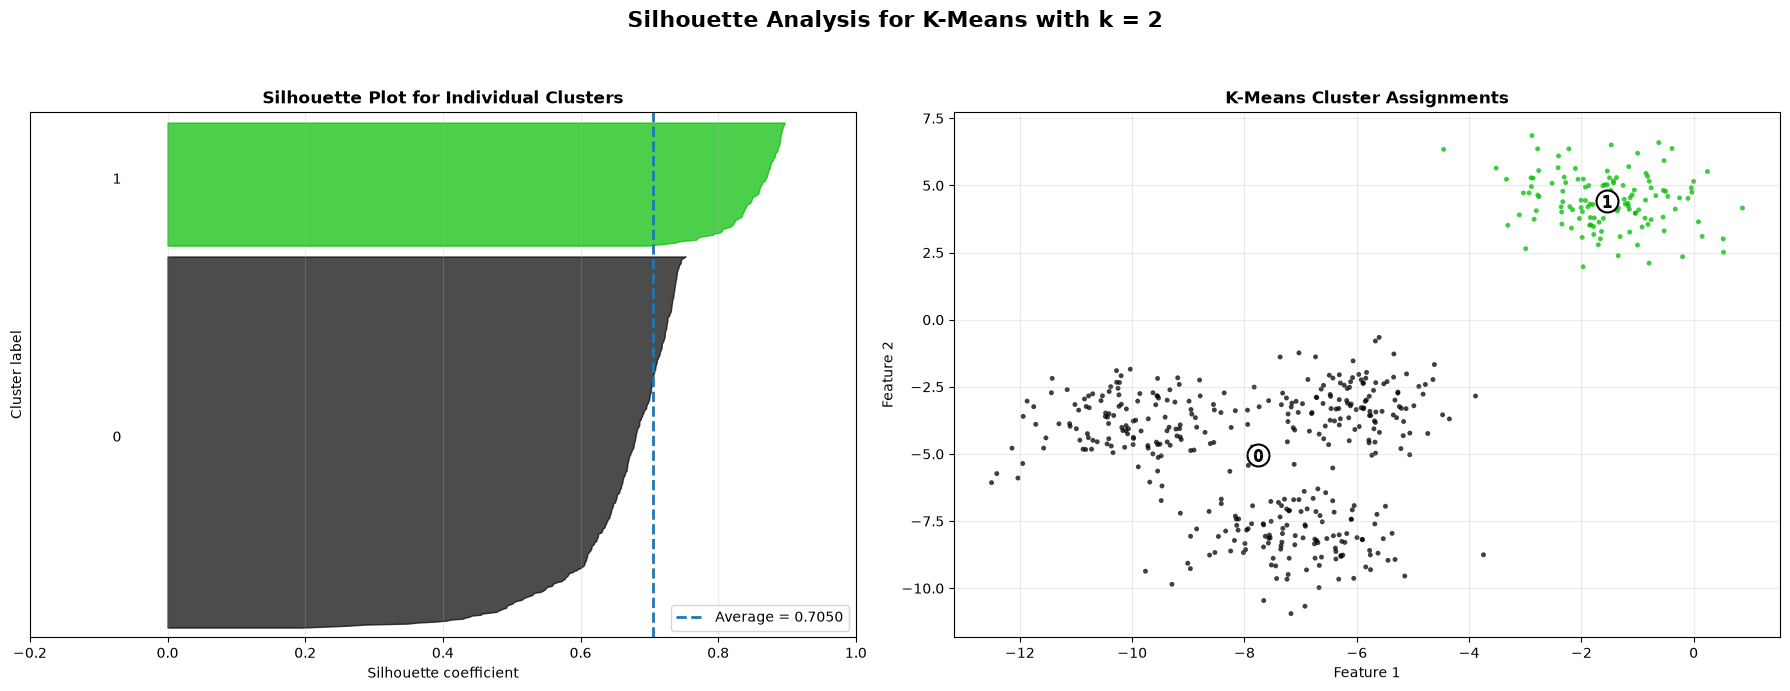

Average silhouette score : 0.704979
Inertia                  : 3735.4057
Iterations               : 3
Cluster sizes            : [375, 125]
Smallest cluster         : 125
Largest cluster          : 375
Cluster-size ratio       : 3.0000
Negative silhouettes     : 0
Figure saved to          : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_k2.png

FITTING K-MEANS WITH k = 3


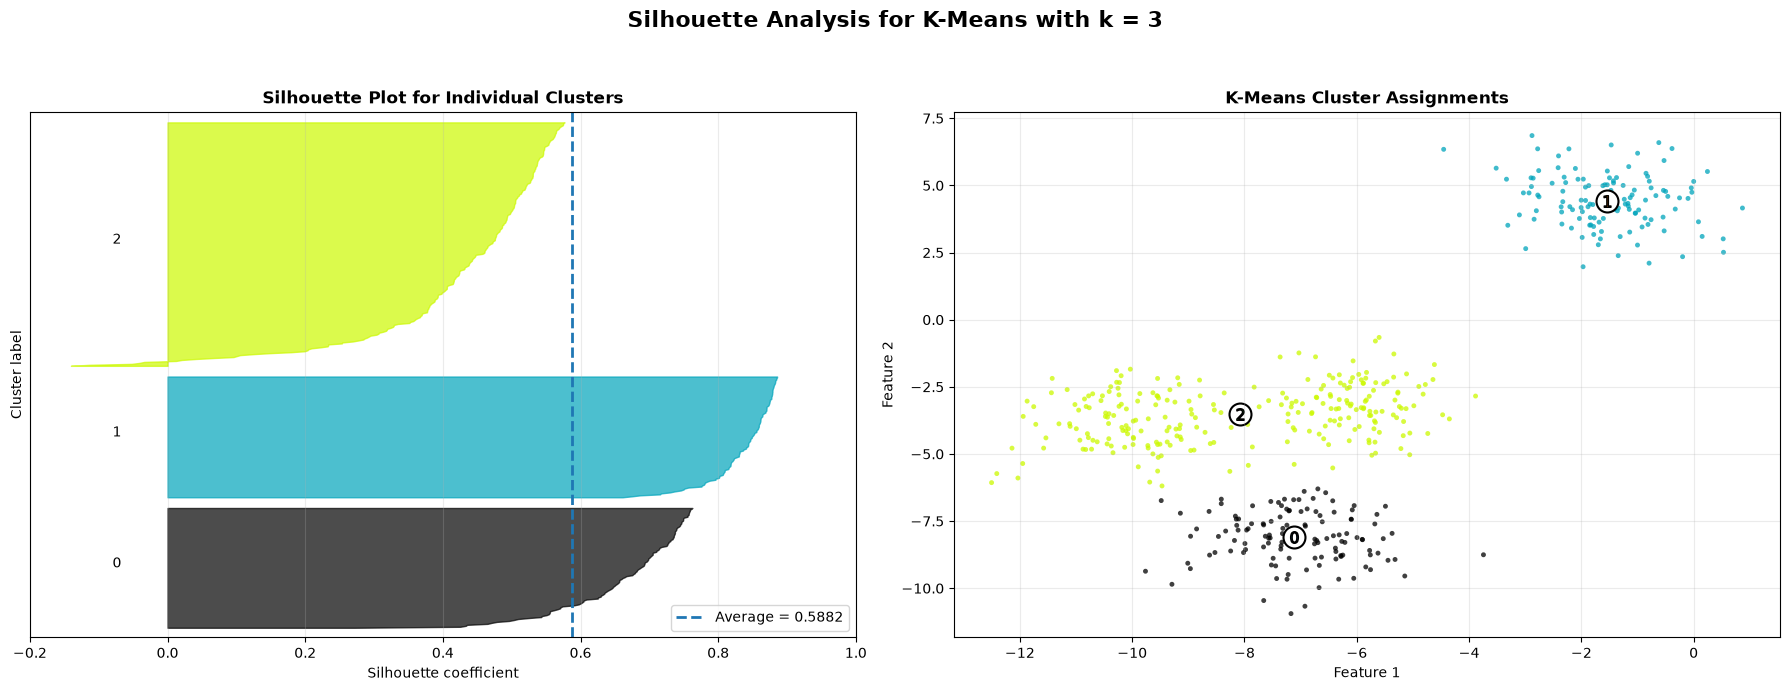

Average silhouette score : 0.588200
Inertia                  : 1903.5608
Iterations               : 9
Cluster sizes            : [124, 125, 251]
Smallest cluster         : 124
Largest cluster          : 251
Cluster-size ratio       : 2.0242
Negative silhouettes     : 5
Figure saved to          : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_k3.png

FITTING K-MEANS WITH k = 4


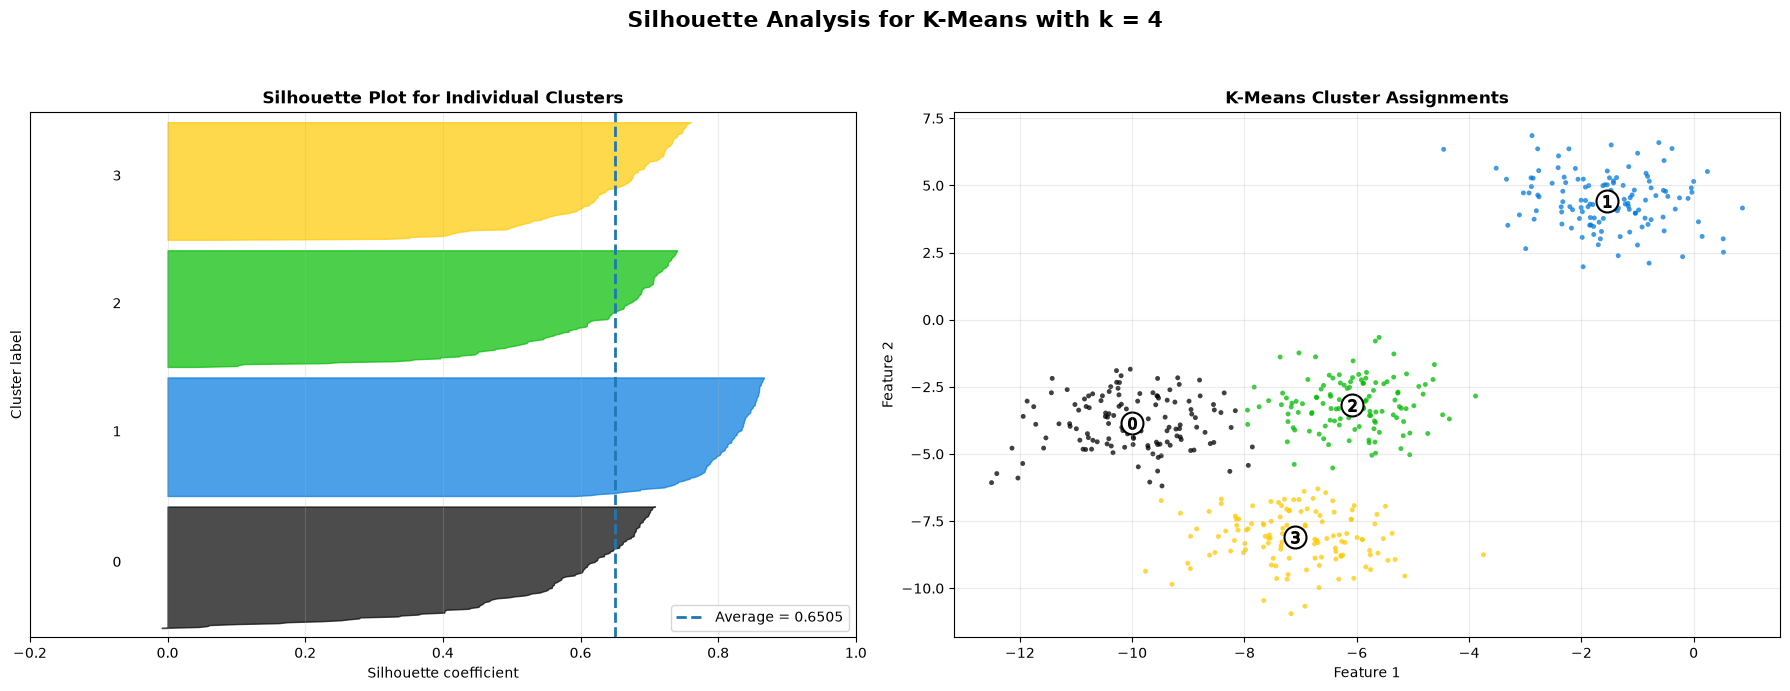

Average silhouette score : 0.650519
Inertia                  : 908.3856
Iterations               : 4
Cluster sizes            : [128, 125, 123, 124]
Smallest cluster         : 123
Largest cluster          : 128
Cluster-size ratio       : 1.0407
Negative silhouettes     : 1
Figure saved to          : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_k4.png

FITTING K-MEANS WITH k = 5


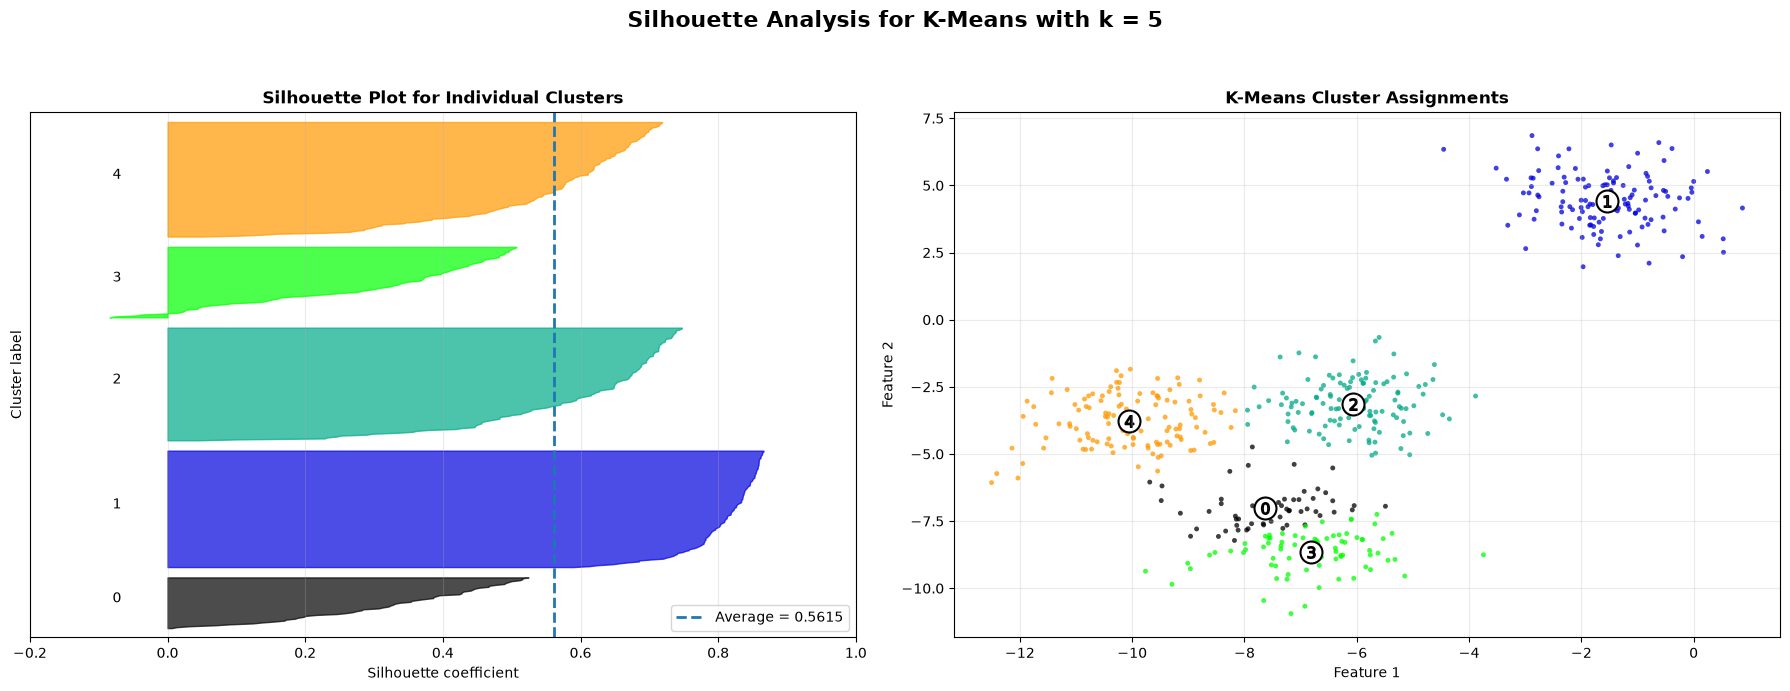

Average silhouette score : 0.561464
Inertia                  : 819.3714
Iterations               : 8
Cluster sizes            : [55, 125, 121, 76, 123]
Smallest cluster         : 55
Largest cluster          : 125
Cluster-size ratio       : 2.2727
Negative silhouettes     : 5
Figure saved to          : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_k5.png

FITTING K-MEANS WITH k = 6


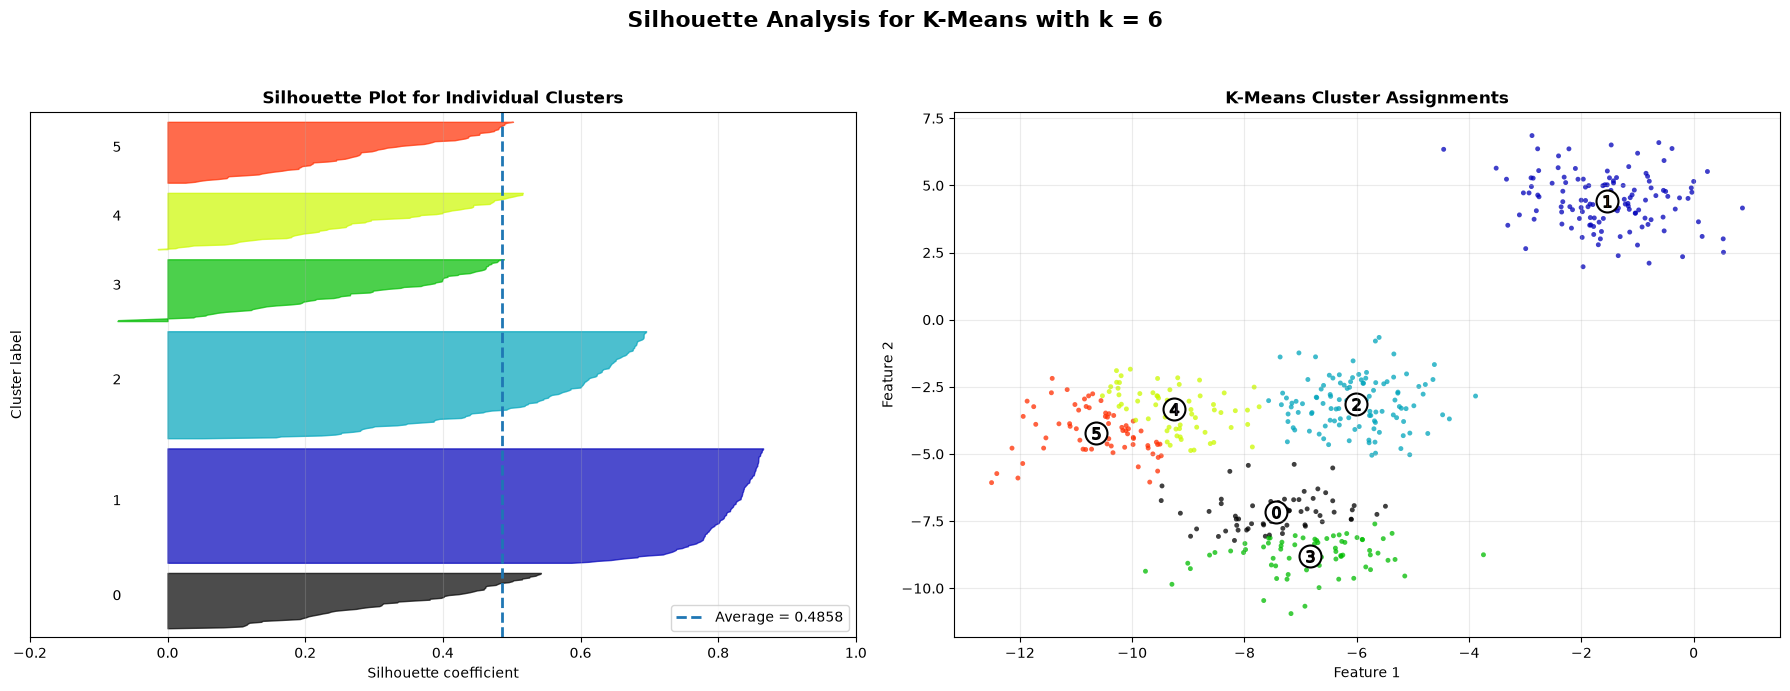

Average silhouette score : 0.485760
Inertia                  : 736.5804
Iterations               : 9
Cluster sizes            : [61, 125, 117, 68, 62, 67]
Smallest cluster         : 61
Largest cluster          : 125
Cluster-size ratio       : 2.0492
Negative silhouettes     : 4
Figure saved to          : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_k6.png



In [8]:
for n_clusters in RANGE_N_CLUSTERS:

    print("=" * 80)
    print(f"FITTING K-MEANS WITH k = {n_clusters}")
    print("=" * 80)

    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init="auto",
        random_state=KMEANS_RANDOM_STATE,
    )

    cluster_labels = model.fit_predict(X)

    fitted_models[n_clusters] = model
    assignment_df[f"Cluster_k{n_clusters}"] = cluster_labels

    silhouette_average = silhouette_score(
        X,
        cluster_labels,
    )

    sample_silhouette_values = silhouette_samples(
        X,
        cluster_labels,
    )

    cluster_counts = np.bincount(
        cluster_labels,
        minlength=n_clusters,
    )

    smallest_cluster = int(cluster_counts.min())
    largest_cluster = int(cluster_counts.max())

    size_ratio = largest_cluster / smallest_cluster

    negative_count = int(
        np.sum(sample_silhouette_values < 0)
    )

    metrics_rows.append(
        {
            "N_Clusters": n_clusters,
            "Silhouette": silhouette_average,
            "Inertia": model.inertia_,
            "Iterations": model.n_iter_,
            "Min_Silhouette": sample_silhouette_values.min(),
            "Max_Silhouette": sample_silhouette_values.max(),
            "Silhouette_STD": sample_silhouette_values.std(),
            "Negative_Count": negative_count,
            "Smallest_Cluster": smallest_cluster,
            "Largest_Cluster": largest_cluster,
            "Size_Ratio": size_ratio,
        }
    )

    for cluster_number, cluster_size in enumerate(
        cluster_counts
    ):
        cluster_size_rows.append(
            {
                "N_Clusters": n_clusters,
                "Cluster": cluster_number,
                "Size": int(cluster_size),
                "Percentage": (
                    100 * cluster_size / len(X)
                ),
            }
        )

    for cluster_number, center in enumerate(
        model.cluster_centers_
    ):
        center_rows.append(
            {
                "N_Clusters": n_clusters,
                "Cluster": cluster_number,
                "Center_Feature_1": center[0],
                "Center_Feature_2": center[1],
            }
        )

    silhouette_plot_path = create_silhouette_figure(
        features=X,
        cluster_labels=cluster_labels,
        silhouette_values=sample_silhouette_values,
        silhouette_average=silhouette_average,
        model=model,
        n_clusters=n_clusters,
    )

    print(f"Average silhouette score : {silhouette_average:.6f}")
    print(f"Inertia                  : {model.inertia_:.4f}")
    print(f"Iterations               : {model.n_iter_}")
    print(f"Cluster sizes            : {cluster_counts.tolist()}")
    print(f"Smallest cluster         : {smallest_cluster}")
    print(f"Largest cluster          : {largest_cluster}")
    print(f"Cluster-size ratio       : {size_ratio:.4f}")
    print(f"Negative silhouettes     : {negative_count}")
    print(f"Figure saved to          : {silhouette_plot_path}")
    print()

##### Explanation :
The approximate model results are:

| Number of clusters | Average silhouette | Inertia | Cluster sizes |
|:---:|:---:|:---:|:---:|
| 2 | 0.70498 | 3735.4057 | 375, 125 |
| 3 | 0.58820 | 1903.5608 | 124, 125, 251 |
| 4 | 0.65052 | 908.3856 | 128, 125, 123, 124 |
| 5 | 0.56146 | 819.3714 | 55, 125, 121, 76, 123 |
| 6 | 0.48576 | 736.5804 | 61, 125, 117, 68, 62, 67 |

The `k = 2` model has the highest average silhouette score. However, it produces one large cluster containing approximately 75% of the observations and one smaller cluster containing approximately 25%.

The `k = 4` model has the second-highest silhouette score and produces four nearly equal-sized clusters. Its visualization also preserves the four visible data groups.

The `k = 5` and `k = 6` models divide some existing groups into smaller clusters, resulting in lower silhouette scores and greater cluster-size imbalance.

## Create Structured Result Tables

This section converts the collected model outputs into three pandas DataFrames:

- `metrics_df`: model-level evaluation statistics
- `cluster_sizes_df`: size and percentage of every cluster
- `centers_df`: coordinates of every cluster centroid

In [9]:
metrics_df = pd.DataFrame(metrics_rows)[
    [
        "N_Clusters",
        "Silhouette",
        "Inertia",
        "Iterations",
        "Min_Silhouette",
        "Max_Silhouette",
        "Silhouette_STD",
        "Negative_Count",
        "Smallest_Cluster",
        "Largest_Cluster",
        "Size_Ratio",
    ]
]


cluster_sizes_df = pd.DataFrame(cluster_size_rows)[
    [
        "N_Clusters",
        "Cluster",
        "Size",
        "Percentage",
    ]
]


centers_df = pd.DataFrame(center_rows)[
    [
        "N_Clusters",
        "Cluster",
        "Center_Feature_1",
        "Center_Feature_2",
    ]
]


print("Structured result tables created successfully.")

Structured result tables created successfully.


##### Explaination :
The result tables provide different levels of information.

`metrics_df` can be used to compare the candidate values of `k`.

`cluster_sizes_df` can be used to determine whether a model produces balanced or highly unequal clusters.

`centers_df` stores the final centroid coordinates produced by every fitted K-Means model.

## Display the Model Results

This section creates rounded copies of the result tables for clear notebook presentation.

The original DataFrames retain their full numerical precision and will be used when saving the CSV result files.

In [10]:
metrics_display = metrics_df.copy()

metrics_display[
    [
        "Silhouette",
        "Inertia",
        "Min_Silhouette",
        "Max_Silhouette",
        "Silhouette_STD",
        "Size_Ratio",
    ]
] = metrics_display[
    [
        "Silhouette",
        "Inertia",
        "Min_Silhouette",
        "Max_Silhouette",
        "Silhouette_STD",
        "Size_Ratio",
    ]
].round(4)


cluster_sizes_display = cluster_sizes_df.copy()
cluster_sizes_display["Percentage"] = (
    cluster_sizes_display["Percentage"].round(2)
)


centers_display = centers_df.copy()

centers_display[
    ["Center_Feature_1", "Center_Feature_2"]
] = centers_display[
    ["Center_Feature_1", "Center_Feature_2"]
].round(4)


print("=" * 100)
print("K-MEANS MODEL COMPARISON")
print("=" * 100)
display(metrics_display)

print("=" * 100)
print("CLUSTER SIZE RESULTS")
print("=" * 100)
display(cluster_sizes_display)

print("=" * 100)
print("CLUSTER CENTERS")
print("=" * 100)
display(centers_display)

K-MEANS MODEL COMPARISON


,N_Clusters,Silhouette,Inertia,Iterations,Min_Silhouette,Max_Silhouette,Silhouette_STD,Negative_Count,Smallest_Cluster,Largest_Cluster,Size_Ratio
0,2,0.7050,"3,735.4057",3,0.1941,0.8964,0.1151,0,125,375,3.0000
1,3,0.5882,"1,903.5608",9,-0.1404,0.8856,0.2023,5,124,251,2.0242
2,4,0.6505,908.3856,4,-0.0087,0.8663,0.1575,1,123,128,1.0407
3,5,0.5615,819.3714,8,-0.0842,0.8658,0.2245,5,55,125,2.2727
4,6,0.4858,736.5804,9,-0.0728,0.8652,0.2473,4,61,125,2.0492


CLUSTER SIZE RESULTS


,N_Clusters,Cluster,Size,Percentage
0,2,0,375,75.0000
1,2,1,125,25.0000
2,3,0,124,24.8000
3,3,1,125,25.0000
4,3,2,251,50.2000
5,4,0,128,25.6000
6,4,1,125,25.0000
7,4,2,123,24.6000
8,4,3,124,24.8000
9,5,0,55,11.0000


CLUSTER CENTERS


,N_Clusters,Cluster,Center_Feature_1,Center_Feature_2
0,2,0,-7.7578,-5.0364
1,2,1,-1.5423,4.4352
2,3,0,-7.1121,-8.0946
3,3,1,-1.5423,4.4352
4,3,2,-8.0807,-3.5073
5,4,0,-10.0097,-3.8494
6,4,1,-1.5423,4.4352
7,4,2,-6.0846,-3.1731
8,4,3,-7.0931,-8.1099
9,5,0,-7.6325,-7.0137


##### Explanation :
The model-comparison table shows that inertia decreases continuously as more clusters are added. This behavior is expected because additional centroids reduce the distances between observations and their assigned centers.

However, the average silhouette score does not improve continuously. It is highest for `k = 2`, followed by `k = 4`.

The cluster-size results show that `k = 4` produces the most balanced solution, with cluster sizes ranging only from approximately 123 to 128 observations.

## Save the Numerical Results

This section saves the complete numerical outputs generated during the analysis.

The following files are created:

- `metrics.csv`
- `cluster_sizes.csv`
- `centers.csv`
- `assignments.csv`
- `metrics_report.txt`

In [11]:
metrics_path = RESULTS_DIR / "metrics.csv"
cluster_sizes_path = RESULTS_DIR / "cluster_sizes.csv"
centers_path = RESULTS_DIR / "centers.csv"
assignments_path = RESULTS_DIR / "assignments.csv"
report_path = RESULTS_DIR / "metrics_report.txt"


metrics_df.to_csv(
    metrics_path,
    index=False,
)

cluster_sizes_df.to_csv(
    cluster_sizes_path,
    index=False,
)

centers_df.to_csv(
    centers_path,
    index=False,
)

assignment_df.to_csv(
    assignments_path,
    index=False,
)


report_text = (
    "K-MEANS NUMBER OF CLUSTERS ANALYSIS\n"
    + "=" * 100
    + "\n\nMODEL COMPARISON\n"
    + "-" * 100
    + "\n"
    + metrics_display.to_string(index=False)
    + "\n\nCLUSTER SIZE RESULTS\n"
    + "-" * 100
    + "\n"
    + cluster_sizes_display.to_string(index=False)
    + "\n\nCLUSTER CENTERS\n"
    + "-" * 100
    + "\n"
    + centers_display.to_string(index=False)
    + "\n"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)


print("=" * 90)
print("NUMERICAL RESULTS SAVED")
print("=" * 90)
print(f"Model metrics       : {metrics_path}")
print(f"Cluster sizes       : {cluster_sizes_path}")
print(f"Cluster centers     : {centers_path}")
print(f"Cluster assignments : {assignments_path}")
print(f"Text report         : {report_path}")
print("=" * 90)

NUMERICAL RESULTS SAVED
Model metrics       : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\metrics.csv
Cluster sizes       : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\cluster_sizes.csv
Cluster centers     : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\centers.csv
Cluster assignments : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\assignments.csv
Text report         : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\metrics_report.txt


##### Explanation :
The CSV files preserve the complete numerical precision of the analysis.

The assignment file contains the predicted cluster label for every observation under each candidate value of `k`. This makes it possible to compare how individual observations move between clusters when the number of clusters changes.

The text report provides a human-readable version of the main numerical tables.

## Compare Average Silhouette Scores

This graph compares the average silhouette score produced by each candidate value of `k`.

A higher average silhouette score usually indicates that observations are more compact within their assigned clusters and better separated from neighboring clusters.

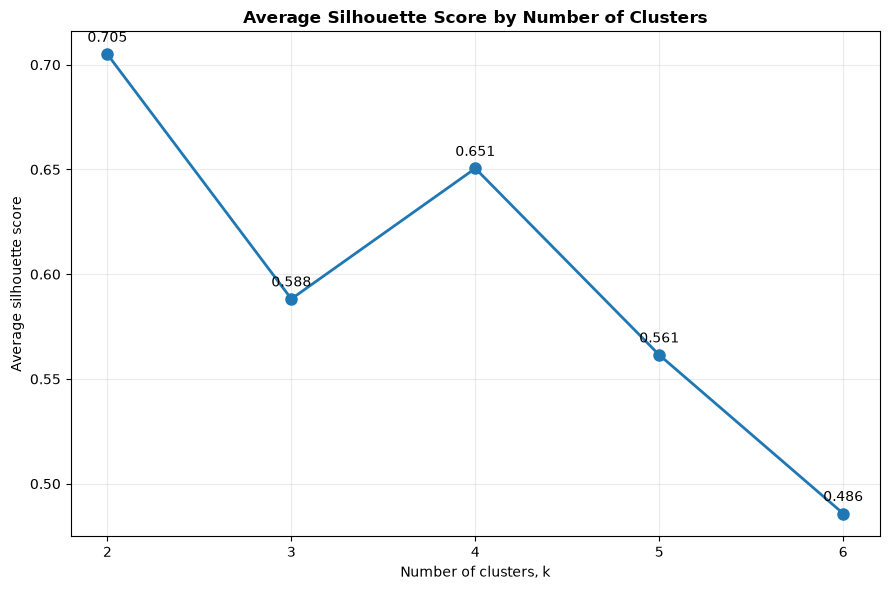

Highest average silhouette score: k = 2, score = 0.704979
Silhouette score plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\silhouette_scores.png


In [12]:
best_silhouette_row = metrics_df.loc[
    metrics_df["Silhouette"].idxmax()
]

best_silhouette_k = int(
    best_silhouette_row["N_Clusters"]
)

best_silhouette_score = float(
    best_silhouette_row["Silhouette"]
)


fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    metrics_df["N_Clusters"],
    metrics_df["Silhouette"],
    marker="o",
    linewidth=2,
    markersize=8,
)

for _, row in metrics_df.iterrows():

    ax.annotate(
        f'{row["Silhouette"]:.3f}',
        (
            row["N_Clusters"],
            row["Silhouette"],
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Average Silhouette Score by Number of Clusters")
ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("Average silhouette score")
ax.set_xticks(RANGE_N_CLUSTERS)

fig.tight_layout()

silhouette_summary_path = (
    PLOTS_DIR / "silhouette_scores.png"
)

fig.savefig(
    silhouette_summary_path,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Highest average silhouette score: "
    f"k = {best_silhouette_k}, "
    f"score = {best_silhouette_score:.6f}"
)

print(
    f"Silhouette score plot saved to: "
    f"{silhouette_summary_path}"
)

##### Explanation :
The graph shows that `k = 2` has the highest average silhouette score of approximately `0.7050`.

The second-highest score occurs at `k = 4`, with an average silhouette score of approximately `0.6505`.

The scores decrease for `k = 5` and `k = 6`, indicating that adding more clusters does not improve the overall separation of the observations.

## Compare K-Means Inertia

Inertia measures the total squared distance between observations and their assigned cluster centroids.

Lower inertia indicates that observations are closer to their assigned centers. However, inertia always decreases when more clusters are added, so the model should not be selected only by choosing the lowest inertia.

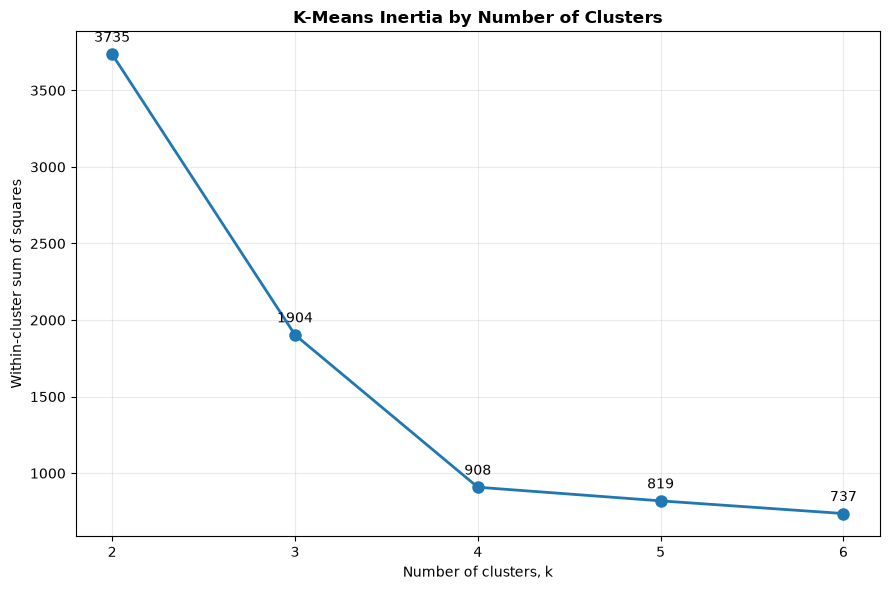

Inertia plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\inertia.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    metrics_df["N_Clusters"],
    metrics_df["Inertia"],
    marker="o",
    linewidth=2,
    markersize=8,
)

for _, row in metrics_df.iterrows():

    ax.annotate(
        f'{row["Inertia"]:.0f}',
        (
            row["N_Clusters"],
            row["Inertia"],
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("K-Means Inertia by Number of Clusters")
ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("Within-cluster sum of squares")
ax.set_xticks(RANGE_N_CLUSTERS)

fig.tight_layout()

inertia_plot_path = PLOTS_DIR / "inertia.png"

fig.savefig(
    inertia_plot_path,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Inertia plot saved to: {inertia_plot_path}")

##### Observation :
The largest reductions in inertia occur when moving from `k = 2` to `k = 3` and from `k = 3` to `k = 4`.

After `k = 4`, the reductions become much smaller:

- From `k = 4` to `k = 5`, inertia decreases only moderately.
- From `k = 5` to `k = 6`, the improvement is smaller again.

This pattern suggests an elbow around `k = 4`, supporting the four-cluster solution.

## Evaluate Cluster-Size Balance

The cluster-size ratio compares the size of the largest cluster with the size of the smallest cluster.

$$
\text{Cluster-size ratio}
=
\frac{\text{Largest cluster size}}
{\text{Smallest cluster size}}
$$

A value close to `1` indicates similarly sized clusters. A larger value indicates greater imbalance.

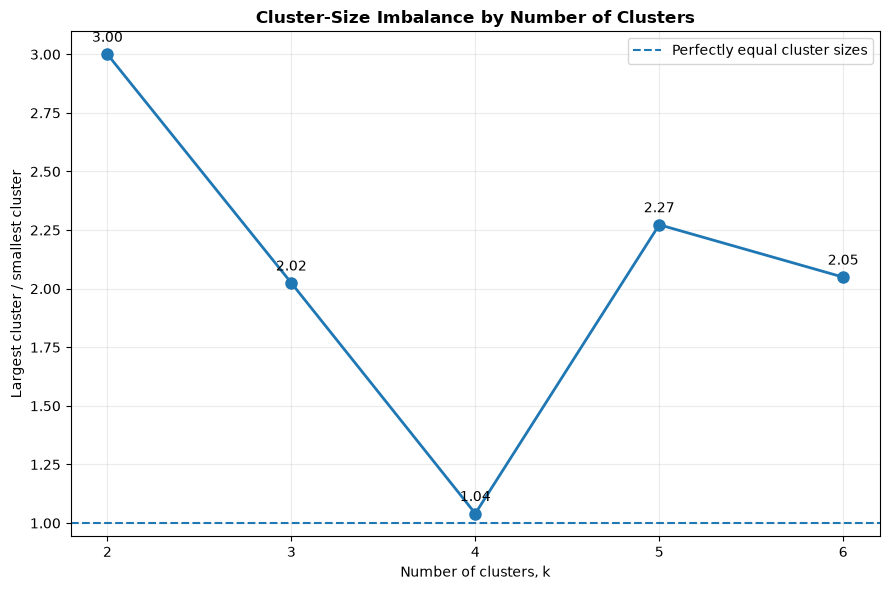

Cluster-balance plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters\cluster_balance.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    metrics_df["N_Clusters"],
    metrics_df["Size_Ratio"],
    marker="o",
    linewidth=2,
    markersize=8,
)

for _, row in metrics_df.iterrows():

    ax.annotate(
        f'{row["Size_Ratio"]:.2f}',
        (
            row["N_Clusters"],
            row["Size_Ratio"],
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

ax.axhline(
    y=1,
    linestyle="--",
    linewidth=1.5,
    label="Perfectly equal cluster sizes",
)

ax.set_title("Cluster-Size Imbalance by Number of Clusters")
ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("Largest cluster / smallest cluster")
ax.set_xticks(RANGE_N_CLUSTERS)
ax.legend()

fig.tight_layout()

balance_plot_path = PLOTS_DIR / "cluster_balance.png"

fig.savefig(
    balance_plot_path,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Cluster-balance plot saved to: "
    f"{balance_plot_path}"
)

##### Explanation :
The `k = 4` model has a cluster-size ratio of approximately `1.04`, which is very close to perfect balance.

The `k = 2` model has a ratio of `3.00`, meaning that its largest cluster is three times the size of its smallest cluster.

The `k = 5` and `k = 6` models also show greater imbalance because some of the existing data groups are divided into smaller clusters.

## Select the Preliminary Value of K

The final value of `k` is selected by considering multiple forms of evidence:

- Average silhouette score
- Inertia
- Cluster-size balance
- Number of negative silhouette values
- Visual separation of the clusters
- Whether the solution preserves the visible data structure

Although `k = 2` has the highest silhouette score, the model combines three nearby groups into one large cluster.

Therefore, `k = 4` is selected as the preliminary solution.

In [15]:
SELECTED_K = 4

selected_results = metrics_df.loc[
    metrics_df["N_Clusters"] == SELECTED_K
].iloc[0]


selection_text = f"""
PRELIMINARY NUMBER OF CLUSTERS SELECTION
{'=' * 80}

Highest average silhouette:
k = {best_silhouette_k}
Average silhouette = {best_silhouette_score:.6f}

Preliminary selected model:
k = {SELECTED_K}
Average silhouette = {selected_results['Silhouette']:.6f}
Inertia = {selected_results['Inertia']:.4f}
Smallest cluster = {int(selected_results['Smallest_Cluster'])}
Largest cluster = {int(selected_results['Largest_Cluster'])}
Cluster-size ratio = {selected_results['Size_Ratio']:.4f}

Interpretation:
The k = 2 solution has the highest average silhouette score. However, its
largest cluster contains approximately three times as many observations as
its smallest cluster. The corresponding visualization shows that three
nearby groups have been combined into one large cluster.

The k = 4 solution has the second-highest average silhouette score and its
clusters have nearly equal sizes. Its visualization preserves the four main
data groups without unnecessarily dividing them.

Therefore, k = 4 is selected as the preliminary solution. This decision uses
the silhouette score, inertia, cluster-size balance, and visual interpretation
rather than relying on only one metric.
""".strip()


print(selection_text)


selection_path = RESULTS_DIR / "selection.txt"

selection_path.write_text(
    selection_text,
    encoding="utf-8",
)

print()
print(f"Selection explanation saved to: {selection_path}")

PRELIMINARY NUMBER OF CLUSTERS SELECTION

Highest average silhouette:
k = 2
Average silhouette = 0.704979

Preliminary selected model:
k = 4
Average silhouette = 0.650519
Inertia = 908.3856
Smallest cluster = 123
Largest cluster = 128
Cluster-size ratio = 1.0407

Interpretation:
The k = 2 solution has the highest average silhouette score. However, its
largest cluster contains approximately three times as many observations as
its smallest cluster. The corresponding visualization shows that three
nearby groups have been combined into one large cluster.

The k = 4 solution has the second-highest average silhouette score and its
clusters have nearly equal sizes. Its visualization preserves the four main
data groups without unnecessarily dividing them.

Therefore, k = 4 is selected as the preliminary solution. This decision uses
the silhouette score, inertia, cluster-size balance, and visual interpretation
rather than relying on only one metric.

Selection explanation saved to: C:\Users\sam

##### Explanation :
The selected `k = 4` model has:

- Average silhouette score: approximately `0.6505`
- Inertia: approximately `908.3856`
- Smallest cluster: approximately `123` observations
- Largest cluster: approximately `128` observations
- Cluster-size ratio: approximately `1.0407`

This model provides a better balance between mathematical quality and the visible structure of the dataset.

The highest silhouette score alone would favor `k = 2`, but that solution combines several meaningful groups. The four-cluster model provides a more informative and structurally appropriate representation.

## Save the Selected Model Results

This section extracts and saves the most important outputs from the selected `k = 4` model.

The saved files contain:

- The selected cluster assignment for every observation
- The size and percentage of each selected cluster
- The coordinates of the selected cluster centers

In [16]:
selected_model = fitted_models[SELECTED_K]

selected_labels = assignment_df[
    f"Cluster_k{SELECTED_K}"
].to_numpy()


selected_clusters_df = sample_data_df[
    [
        "Sample_ID",
        "Feature_1",
        "Feature_2",
    ]
].copy()

selected_clusters_df["Cluster"] = selected_labels


selected_cluster_sizes_df = (
    selected_clusters_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Size")
)

selected_cluster_sizes_df["Percentage"] = (
    100
    * selected_cluster_sizes_df["Size"]
    / len(selected_clusters_df)
)


selected_centers_df = pd.DataFrame(
    selected_model.cluster_centers_,
    columns=[
        "Center_Feature_1",
        "Center_Feature_2",
    ],
)

selected_centers_df.insert(
    0,
    "Cluster",
    np.arange(SELECTED_K),
)


selected_clusters_path = (
    RESULTS_DIR / "selected_clusters.csv"
)

selected_sizes_path = (
    RESULTS_DIR / "selected_sizes.csv"
)

selected_centers_path = (
    RESULTS_DIR / "selected_centers.csv"
)


selected_clusters_df.to_csv(
    selected_clusters_path,
    index=False,
)

selected_cluster_sizes_df.to_csv(
    selected_sizes_path,
    index=False,
)

selected_centers_df.to_csv(
    selected_centers_path,
    index=False,
)


print("=" * 80)
print(f"SELECTED MODEL RESULTS: k = {SELECTED_K}")
print("=" * 80)

print("Cluster sizes:")
display(selected_cluster_sizes_df.round(4))

print("Cluster centers:")
display(selected_centers_df.round(4))

print("=" * 80)
print("SELECTED RESULTS SAVED")
print("=" * 80)
print(f"Assignments : {selected_clusters_path}")
print(f"Sizes       : {selected_sizes_path}")
print(f"Centers     : {selected_centers_path}")
print("=" * 80)

SELECTED MODEL RESULTS: k = 4
Cluster sizes:


,Cluster,Size,Percentage
0,0,128,25.6000
1,1,125,25.0000
2,2,123,24.6000
3,3,124,24.8000


Cluster centers:


,Cluster,Center_Feature_1,Center_Feature_2
0,0,-10.0097,-3.8494
1,1,-1.5423,4.4352
2,2,-6.0846,-3.1731
3,3,-7.0931,-8.1099


SELECTED RESULTS SAVED
Assignments : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\selected_clusters.csv
Sizes       : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\selected_sizes.csv
Centers     : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters\selected_centers.csv


##### Explanation :
The selected four-cluster model produces the following approximate cluster sizes:

| Cluster | Size | Percentage |
|:---:|:---:|:---:|
| 0 | 128 | 25.6% |
| 1 | 125 | 25.0% |
| 2 | 123 | 24.6% |
| 3 | 124 | 24.8% |

The percentages are close to 25% for every cluster, showing that the selected solution is highly balanced.

The cluster labels `0`, `1`, `2`, and `3` are arbitrary identifiers. They do not indicate clinical importance, quality, severity, or ranking.

## Display the Saved Files

This final section lists all plot and result files created by the notebook.

It also confirms the selected preliminary number of clusters and the output directories used by the analysis.

In [17]:
plot_files = sorted(
    path.name
    for path in PLOTS_DIR.glob("*.png")
)

result_files = sorted(
    path.name
    for path in RESULTS_DIR.iterdir()
    if path.is_file()
)


print("=" * 80)
print("SAVED PLOT FILES")
print("=" * 80)

for file_number, file_name in enumerate(
    plot_files,
    start=1,
):
    print(f"{file_number:>2}. {file_name}")


print()
print("=" * 80)
print("SAVED RESULT FILES")
print("=" * 80)

for file_number, file_name in enumerate(
    result_files,
    start=1,
):
    print(f"{file_number:>2}. {file_name}")


print()
print("=" * 100)
print("NOTEBOOK COMPLETED SUCCESSFULLY")
print("=" * 100)
print(
    f"Selected preliminary number of clusters: "
    f"k = {SELECTED_K}"
)
print(f"Plots saved in   : {PLOTS_DIR}")
print(f"Results saved in : {RESULTS_DIR}")
print("=" * 100)

SAVED PLOT FILES
 1. cluster_balance.png
 2. inertia.png
 3. sample_data.png
 4. silhouette_k2.png
 5. silhouette_k3.png
 6. silhouette_k4.png
 7. silhouette_k5.png
 8. silhouette_k6.png
 9. silhouette_scores.png

SAVED RESULT FILES
 1. assignments.csv
 2. centers.csv
 3. cluster_sizes.csv
 4. metrics.csv
 5. metrics_report.txt
 6. sample_data.csv
 7. selected_centers.csv
 8. selected_clusters.csv
 9. selected_sizes.csv
10. selection.txt

NOTEBOOK COMPLETED SUCCESSFULLY
Selected preliminary number of clusters: k = 4
Plots saved in   : C:\Users\samsa\Documents\Capstone Project\Project\plots\number_of_clusters
Results saved in : C:\Users\samsa\Documents\Capstone Project\Project\results\number_of_clusters
